In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint, choice



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'

DIR_TRAINED = "TRAINED_MODELS"

SAMPLING = '60min'
SAMPLING_MIN = 60
MONTHS_HISTORY = 8

# CREATION GRAPH

In [2]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [3]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,70.89,70.89,187.51,187.51,70.89,67.64,116.62,73.91,52.57,3.25,12.87,2.20,6.27,41.54,1.17,52.57
2024-01-01 01:00:00,83.72,83.72,240.73,240.73,83.72,80.06,157.01,87.35,65.37,3.66,14.69,0.00,7.29,67.88,1.77,65.37
2024-01-01 02:00:00,64.94,64.94,199.59,199.59,64.94,61.29,134.64,67.32,41.79,3.65,19.50,0.00,6.02,65.37,1.96,41.79
2024-01-01 03:00:00,77.43,77.43,197.07,197.07,77.43,74.10,119.64,83.49,63.30,3.33,10.80,0.00,9.39,35.01,1.14,63.30
2024-01-01 04:00:00,71.09,71.09,208.94,208.94,71.09,66.68,137.85,73.87,54.43,4.41,12.25,0.00,7.19,62.38,1.61,54.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,960.44,960.44,2813.98,2813.98,960.44,913.25,1853.54,1057.84,476.36,47.19,153.54,283.36,144.59,779.32,16.38,476.36
2024-06-28 20:00:00,745.39,745.39,2143.38,2143.38,745.39,707.21,1397.99,830.29,380.54,38.18,119.33,207.33,123.08,554.45,13.26,380.54
2024-06-28 21:00:00,835.15,835.15,2381.77,2381.77,835.15,797.71,1546.62,920.58,443.85,37.44,121.43,232.43,122.87,610.78,15.27,443.85
2024-06-28 22:00:00,1255.06,1255.06,3581.79,3581.79,1255.06,1197.25,2326.72,1371.27,657.64,57.81,204.42,335.19,174.02,933.95,21.50,657.64


# GMAN MATRICES

## ADJACENCY MATRIX

In [4]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## INCIDENCE MATRIX

In [5]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: -0.00030000000000574093


## NODE MASKS

In [6]:
INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']


## MASK ATTENTION MASK

In [7]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=1):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask

NODE_LIST_IDX = {x:i for i,x in enumerate(NODE_LIST)}
ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)

for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']:
    ATT_MASK[NODE_LIST_IDX[node_idx], NODE_LIST_IDX[node_idx]] = True

ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")

ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)

ATT_MASK_DF



ATT_MASK_DF = pd.DataFrame(np.zeros((16, 16), dtype=bool), columns=NODE_LIST, index=NODE_LIST)
for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S1','S2','S3','S4','S5','S6','S7']:
    ATT_MASK_DF.loc[node_idx,node_idx] = True


display(ATT_MASK_DF)
ATT_MASK_T = torch.tensor(ATT_MASK_DF.values).to(torch.bool)


--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_A,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
HR_B,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_B,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
C,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
D,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
A,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
B,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
E,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
S7,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


### ATT MASK 2

In [12]:
def create_adjacency_mask(adjacency_matrix, penalty=-1e9):
    """
    Converts a binary adjacency matrix into an additive attention mask.
    adjacency_matrix: (16, 16) tensor where 1 = connected, 0 = disconnected.
    """
    # Initialize a mask heavily penalizing all connections
    mask = torch.full_like(adjacency_matrix, penalty, dtype=torch.float32)
    
    # Ensure every node can attend to itself (add self-loops if missing)
    eye = torch.eye(adjacency_matrix.size(0), device=adjacency_matrix.device)
    adj_with_self_loops = torch.clamp(adjacency_matrix + eye, max=1.0)
    
    # Where nodes are connected, remove the penalty (set to 0.0)
    mask = torch.where(adj_with_self_loops > 0, torch.zeros_like(mask), mask)
    
    # The resulting mask is (16, 16) and ready for the Transformer
    return mask

ATT_MASK_T = create_adjacency_mask( torch.tensor(nx.to_numpy_array(G_router)))

pd.DataFrame( ATT_MASK_T.numpy(), columns=NODE_LIST, index=NODE_LIST).astype(int)

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
MR_A,-1000000000,0,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
HR_B,-1000000000,-1000000000,0,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
MR_B,-1000000000,0,-1000000000,0,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
C,-1000000000,-1000000000,-1000000000,-1000000000,0,0,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
D,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,0,-1000000000,0,0,-1000000000,-1000000000,-1000000000,-1000000000
A,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,0,-1000000000
B,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000
E,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0
S7,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000


# PARAMETERS

In [13]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
#FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
#FREQ_MINUTES = FREQ_H*60

NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
PRED_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 256

STEPS_PER_DAY = int(24*60/SAMPLING_MIN)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 8
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {SAMPLING_MIN} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 24
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 256
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 8
Dimension of each head: 32


# DATASETS / DATALOADERS

In [119]:

import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowSensorDataset(Dataset):
    def __init__(self, raw_time_series, known_sensor_indices, window_size=24, stride=1):
        """
        raw_time_series: Tensor of shape (Total_Time_Steps, 16)
        known_sensor_indices: List of the 7 fixed sensor indices
        seq_len: The number of time steps to look at (24)
        stride: How many steps to jump forward for the next sample. 
                stride=1 gives maximum data (high overlap).
                stride=24 gives zero overlap.
        """
        self.data = raw_time_series
        self.window_size = window_size
        self.stride = stride
        
        # Setup static masks
        self.known_indices = torch.tensor(known_sensor_indices, dtype=torch.long)
        num_total_sensors = raw_time_series.shape[1]
        
        all_indices = torch.arange(num_total_sensors)
        self.missing_indices = all_indices[~torch.isin(all_indices, self.known_indices)]
        
        self.missing_mask = torch.zeros(num_total_sensors, dtype=torch.bool)
        self.missing_mask[self.missing_indices] = True

    def __len__(self):
        # Calculate how many full windows we can extract
        return (self.data.shape[0] - self.window_size) // self.stride + 1

    def __getitem__(self, idx):
        # 1. Calculate the actual start and end index in the continuous data
        start_idx = idx * self.stride
        end_idx = start_idx + self.window_size
        
        # 2. Slice the 24-step window. Shape is currently (24, 16)
        window = self.data[start_idx:end_idx].clone()
        
        # 3. Transpose to match the model's expected shape: (16, 24)
        target_y = window.t()
        
        # 4. Create the input by masking the missing sensors to 0.0
        masked_x = target_y.clone()
        masked_x[self.missing_indices, :] = 0.0
        
        return masked_x.float(), target_y.float(), self.missing_mask


LEAF_INDICES = [9,11,12,13,14,15]

total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size


train_data = torch.tensor(DATA_RAW_MODEL[:train_size].copy().values)
val_data = torch.tensor(DATA_RAW_MODEL[train_size:].copy().values)

TSS_TRAIN_DS = SlidingWindowSensorDataset(train_data, LEAF_INDICES, HIST_STEPS)
TSS_VAL_DS = SlidingWindowSensorDataset(val_data, LEAF_INDICES, HIST_STEPS)

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")



TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")

if DEBUG:
    from random import randint

    _rand_idx = randint(0,len(TSS_TRAIN_DS))
    print()
    print(f"Random index: {_rand_idx}")
    X_real = DATA_RAW_MODEL.values[_rand_idx]
    print()
    print("X real:")
    print(X_real)

    _sample = TSS_TRAIN_DS[_rand_idx]

    X_masked = _sample[0]
    Y_real = _sample[1]
    _mask = _sample[2]
    print(f"X masked: {X_masked.shape}")
    print(X_masked[-1])
    print()
    print(f"Y real: {Y_real.shape}")
    print(Y_real[-1])

    print(f"Mask: {_mask}")

    print()
    for X_d, Y_real,_mask in TSS_TRAIN_DL:

        if randint(0,100) == 4:
            break

    print("#######################")
    print(_mask.shape)
    

 



Total valid sliding windows: 4320
Train size: 3433
Val size: 841
Train samples: 108 | Val samples: 27

Random index: 2422

X real:
[1373.13 1373.13 3776.95 3776.95 1373.13 1316.82 2403.82 1464.01  710.26
   56.31  205.06  401.5   147.19  916.24   23.57  710.26]
X masked: torch.Size([16, 24])
tensor([710.2600, 570.1400,  39.9700,  46.9300,  38.1900,  30.3900,  37.9900,
         33.3400,  33.5700,  28.8700,  31.2900,  46.6400,  59.3100,  89.5300,
        115.2700, 130.5700, 158.1700, 179.8100, 305.0000, 387.5200, 452.2800,
        533.7600, 437.2100, 483.4700])

Y real: torch.Size([16, 24])
tensor([710.2600, 570.1400,  39.9700,  46.9300,  38.1900,  30.3900,  37.9900,
         33.3400,  33.5700,  28.8700,  31.2900,  46.6400,  59.3100,  89.5300,
        115.2700, 130.5700, 158.1700, 179.8100, 305.0000, 387.5200, 452.2800,
        533.7600, 437.2100, 483.4700])
Mask: tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True, False,
         True, False, False, False, False, Fals

# MODEL
## ITransformer

In [42]:
NUM_NODES

16

In [120]:
import torch.nn as nn

class GraphBiasediTransformer(nn.Module):
    def __init__(self, num_nodes=16, time_steps=24, d_model=128, nhead=8, num_layers=3, dim_feedforward=512):
        super().__init__()
        
        # 1. Temporal embedding: Project 24 time steps to hidden dimension
        self.projector = nn.Linear(time_steps, d_model)
        
        # 2. Spatial embedding: Give each of the 16 sensors a strict physical identity
        self.node_embedding = nn.Parameter(torch.randn(1, num_nodes, d_model))
        
        self.layer_norm = nn.LayerNorm(d_model)
        
        # 3. Transformer Encoder configured for batch_first
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Reconstruct the 24 time steps
        self.head = nn.Linear(d_model, time_steps)

    def forward(self, x, adj_mask):
        """
        x: (Batch, 16, 24) - The input time series (9 sensors masked to 0)
        adj_mask: (16, 16) - The additive topological bias
        """
        # Embed temporal data and inject the specific sensor's identity
        x_enc = self.projector(x) + self.node_embedding
        x_enc = self.layer_norm(x_enc)
        
        # Pass through the encoder, applying the structural graph mask.
        # This restricts information flow strictly to physical neighbors.
        enc_out = self.encoder(x_enc, mask=adj_mask)
        
        # Map back to standard time series domain
        reconstruction = self.head(enc_out)
        
        return reconstruction

if DEBUG:

    projector =  nn.Linear(HIST_STEPS , D_MODEL)
    node_embedding = nn.Parameter(torch.randn(1, NUM_NODES, D_MODEL))
    layer_norm = nn.LayerNorm(D_MODEL)

    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=512,
            batch_first=True,
            activation="gelu"
        )
    encoder = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS_ENC_DEC)
    head = nn.Linear(D_MODEL, HIST_STEPS)

    for X_d, Y_d,_ in TSS_TRAIN_DL:
        if randint(0,10) == 4:
            break

    x_enc = projector(X_d) + node_embedding
    print(f"x_enc.shape: {x_enc.shape}")

    x_enc = layer_norm(x_enc)
    print(f"x_enc.shape: {x_enc.shape}")

    enc_out = encoder(x_enc, mask=ATT_MASK_T)
    print(f"enc_out.shape: {enc_out.shape}")

    reconstruction = head(enc_out)
    print(f"reconstruction.shape: {reconstruction.shape}")

    

x_enc.shape: torch.Size([32, 16, 256])
x_enc.shape: torch.Size([32, 16, 256])
enc_out.shape: torch.Size([32, 16, 256])
reconstruction.shape: torch.Size([32, 16, 24])


# TRAINNIG

In [121]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


### LOSS FUNCTION

In [122]:
import torch
import torch.nn.functional as F

INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX, dtype=torch.float32)
INCIDENCE_MATRIX_T.shape

INNER_NODES_MASK_BOOL = INNER_NODES_MASK.astype(bool).values


def physics_informed_loss(predictions, targets, bool_mask, incidence_matrix, lambda_physics=0.1):
    """
    predictions: (Batch, 16, 24)
    targets: (Batch, 16, 24)
    bool_mask: (16,) True for the 9 masked sensors
    """
    # 1. Standard Data Loss (MSE on the 9 masked sensors)
    # Using the bool_mask to only calculate error on what was predicted
    mse_loss = F.mse_loss(predictions[:, bool_mask, :], targets[:, bool_mask, :])
    
    # 2. Physics Loss (Flow Conservation across ALL 16 sensors)
    # Recombine the 7 known sensors with the 9 predicted sensors to check total network balance
    full_network_state = targets.clone()
    full_network_state[:, bool_mask, :] = predictions[:, bool_mask, :]
    
    # Calculate net flow at each node: Incidence Matrix * Network State
    # Ideally, for intermediate nodes, this should be very close to 0 (Flow In = Flow Out)
    # Equation: $\sum \text{flow}_{in} - \sum \text{flow}_{out} = 0$
    net_flow = torch.matmul(incidence_matrix, full_network_state)
    
    # The penalty is how far away the network is from perfect conservation
    physics_penalty = torch.mean(torch.abs(net_flow))
    
    # Combine the losses
    total_loss = mse_loss + (lambda_physics * physics_penalty)
    
    return total_loss, mse_loss,physics_penalty


def pinns_loss(predictions, targets, mask, incidence, lambda_phys=0.1):
    # 1. Data Loss: Mean Squared Error strictly on the 9 missing sensors
    # mask shape is (16,), indexing retrieves only the True (missing) sensors
    mse = F.mse_loss(predictions[:, mask, :], targets[:, mask, :])
    
    # 2. Reconstruct the full network state
    full_state = targets.clone()
    full_state[:, mask, :] = predictions[:, mask, :]
    
    # 3. Physics Loss: Kirchhoff's Flow Conservation
    # incidence: (Junctions, Sensors)
    # full_state: (Batch, Sensors, Time_Steps)
    # einsum maps this to calculate net flow at each Junction per Batch per Time_Step
    net_flow = torch.einsum('js,bst->bjt', incidence, full_state)
    
    # The physical penalty is the absolute deviation from zero net flow
    physics_penalty = torch.mean(torch.abs(net_flow))
    
    return mse + (lambda_phys * physics_penalty), mse, physics_penalty

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

    print()

    for X_d, Y_real,_ in TSS_TRAIN_DL:

        if randint(0,100) == 4:
            break

    print(f"Y_real {Y_real.shape}")

    _loss_fn = pinns_loss(Y_real, Y_real, INNER_NODES_MASK_BOOL, INCIDENCE_MATRIX_T)
    print(_loss_fn)



The average loss is: 0.001000000000008286

Y_real torch.Size([32, 16, 24])
(tensor(0.0001), tensor(0.), tensor(0.0015))


In [107]:
INNER_NODES_MASK_BOOL

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False])

In [199]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
).to(DEVICE)




PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR) #LR)



Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask_node_sim.pth


### TRAINING

In [200]:
PATIENCE = 10

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

CHECKPOINT_PATH = f'{DIR_TRAINED}/best_early_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, delta=10, path=CHECKPOINT_PATH)

Checkpoint path: TRAINED_MODELS/best_early_model_itransformer_att_phy_mask_node_sim.pth


In [201]:
MODEL.train()


INNER_NODES_MASK_T = torch.tensor(INNER_NODES_MASK.astype(bool).values)


epoch_mse_loss_arr = []
epoch_phy_loss_arr = []

EPOCHS = 60
for epoch in range(EPOCHS):
    total_loss = 0.0
    total_mse = 0.0
    total_phys = 0.0
    
    for batch_x, batch_y, batch_mask in TSS_TRAIN_DL:
        # Move batch data to GPU/CPU
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        # The mask is the same for every batch in this fixed-sensor setup, 
        # but we take the first one from the batch for indexing
        bool_mask = batch_mask[0].to(DEVICE) 
  
        
        optimizer.zero_grad()
        
        # Forward pass (injecting the graph structure via adj_mask)
        predictions = MODEL(x=batch_x, adj_mask=ATT_MASK_T.to(DEVICE))
        
        # Calculate dual-objective loss
        loss, mse_val, phys_val = pinns_loss(
            predictions=predictions, 
            targets=batch_y, 
            mask=bool_mask, 
            incidence=INCIDENCE_MATRIX_T.to(DEVICE), 
            lambda_phys=1 # Adjust this weight based on priority
        )
        
        # Backpropagation
        loss.backward()
        
        # Gradient clipping is highly recommended for Transformer architectures
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        total_mse += mse_val.item()
        total_phys += phys_val.item()
    
    # Early Stopping
    early_stopping(total_loss, MODEL)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training stopped.")
        break

    # Load best model
    MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
    print("Best model weights loaded for testing.")


    
    epoch_mse_loss_arr.append(total_mse/len(TSS_TRAIN_DL))
    epoch_phy_loss_arr.append(total_phys/len(TSS_TRAIN_DL))

    # Logging metrics per epoch
    num_batches = len(TSS_TRAIN_DL)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Total Loss: {total_loss/num_batches:.4f} | "
          f"MSE: {total_mse/num_batches:.4f} | "
          f"Physics: {total_phys/num_batches:.4f}")

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Validation loss decreased (inf --> 75934392.875000).  Saving model ...
Best model weights loaded for testing.
Epoch 001/60 | Total Loss: 703096.2303 | MSE: 703018.0897 | Physics: 78.1391
Validation loss decreased (75934392.875000 --> 71182006.500000).  Saving model ...
Best model weights loaded for testing.
Epoch 002/60 | Total Loss: 659092.6528 | MSE: 659007.0943 | Physics: 85.5579
Validation loss decreased (71182006.500000 --> 65171006.500000).  Saving model ...
Best model weights loaded for testing.
Epoch 003/60 | Total Loss: 603435.2454 | MSE: 603342.4531 | Physics: 92.7945
Validation loss decreased (65171006.500000 --> 59134503.437500).  Saving model ...
Best model weights loaded for testing.
Epoch 004/60 | Total Loss: 547541.6985 | MSE: 547440.3585 | Physics: 101.3384
Validation loss decreased (59134503.437500 --> 53896598.187500).  Saving model ...
Best model weights loaded for testing.
Epoch 005/60 | Total Loss: 499042.5758 | MSE: 498937.5211 | Physics: 105.0552
Validation loss

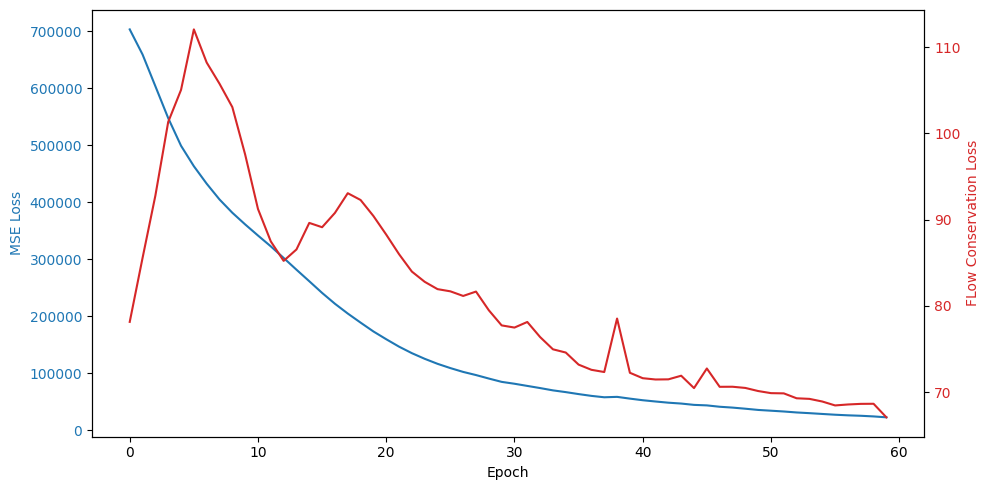

In [202]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss', color='tab:blue')
ax1.plot(epoch_mse_loss_arr, color='tab:blue', label='MSE Loss')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('FLow Conservation Loss', color='tab:red')
ax2.plot(epoch_phy_loss_arr, color='tab:red', label='FLow Conservation Loss')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.show()



### RECONSTRUCTION OF FLOWS

In [203]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
)



PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

### VALIDATION

In [204]:

def validate_model(model, dataloader, criterion, att_mask, device,  channel=None):
    """
    Validates the model and calculates Scaled Loss, Real MAE, and Real RMSE.
    """

    if channel is not None:
        print(f"Channel: {channel}")
    
    model.eval()
    
    total_scaled_loss = 0.0
    total_real_mae = 0.0
    total_real_mse = 0.0  
    

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X_masked, Y_true,_) in enumerate(dataloader):
            
            X_masked = X_masked.to(device)
            Y_true = Y_true.to(device)
            
            # Forward Pass
            Y_pred = model(x=X_masked, adj_mask=att_mask)
            
            # Calculate Scaled Loss (MSE for backprop monitoring)
            loss = criterion(Y_pred, Y_true)
            total_scaled_loss += loss.item()
            
 
            if channel is not None:
                Y_pred = Y_pred[:, :, channel]
                Y_true = Y_true[:, :, channel]
            
            mae = torch.mean(torch.abs(Y_pred - Y_true))
            total_real_mae += mae.item()
            
            mse_real = torch.mean((Y_pred - Y_true) ** 2)
            total_real_mse += mse_real.item()
            
    # Calculate averages over all batches
    avg_scaled_loss = total_scaled_loss / len(dataloader)
    avg_real_mae = total_real_mae / len(dataloader)
    avg_real_mse = total_real_mse / len(dataloader)
    
    # RMSE is the square root of the overall average MSE <-- ADDED
    avg_real_rmse = avg_real_mse ** 0.5
    
    return avg_scaled_loss, avg_real_mae, avg_real_rmse

def validate_plots(model, dataloader, scaler_mean, scaler_std, device, num_nodes_to_plot=3):
    import random
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """

    model.eval()
    means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
    scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)


    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
  
    X, Y_true_scaled = next(iter(dataloader))


    # Move to Device
    X = X.to(device)
    B,T,C = X.shape
    
    # 2. Inference
    with torch.no_grad():
        Y_pred_scaled = model(X)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps

    Y_true_real = (Y_true_scaled * scale) + means
    Y_pred_real = (Y_pred_scaled * scale) + means
        

    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Reconstruction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()



In [205]:

criterion = torch.nn.MSELoss()

#ERR_TABLE_NODE = []
#for i,node in enumerate(NODE_LIST):
#    val_loss, val_mae, val_rmse = validate_model(MODEL, TSS_VAL_DL, criterion, ATT_MASK_T, 'cpu', channel=i)
#    ERR_TABLE_NODE.append([val_loss, val_mae, val_rmse])

#ERR_TABLE_NODE = pd.DataFrame(ERR_TABLE_NODE, columns=['Loss', 'MAE', 'RMSE'], index=NODE_LIST).T.round(1)


#validate_plots(MODEL, TSS_VAL_DL, SCALER_MEAN_T, SCALER_STD_T, 'cpu', num_nodes_to_plot=3)

#axs = []
#for i in range(LAYERS_ENC_DEC):
#    axs.append(analyze_itransformer_attention(MODEL, TSS_VAL_DL, NODE_LIST, layer_index=i, device='cpu')[1])

val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, ATT_MASK_T, 'cpu', channel=None)
print(f"Validation Loss: {val_loss_total}")
print(f"Validation MAE: {val_mae_total}")
print(f"Validation RMSE: {val_rmse_total}")

Validation Loss: 23836.141927083332
Validation MAE: 95.85298495822482
Validation RMSE: 154.3895784277013


In [ ]:


_output_excel = f'XLS_MODELS/{PREFIX_MODEL}_{SAMPLING}_table.csv'
print(f"Output Excel: {_output_excel}")
ERR_TABLE_NODE.to_csv(_output_excel, sep=';')

Output Excel: XLS_MODELS/model_itransformer_att_phy_mask_node_sim_60min_table.csv


## SCENARIOS: WHAT IF PREDICTION


In [206]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
)



PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

### SCENARIO: NO MODIFICATION

X_masked: torch.Size([1, 16, 24])
Y_pred: torch.Size([1, 16, 24])


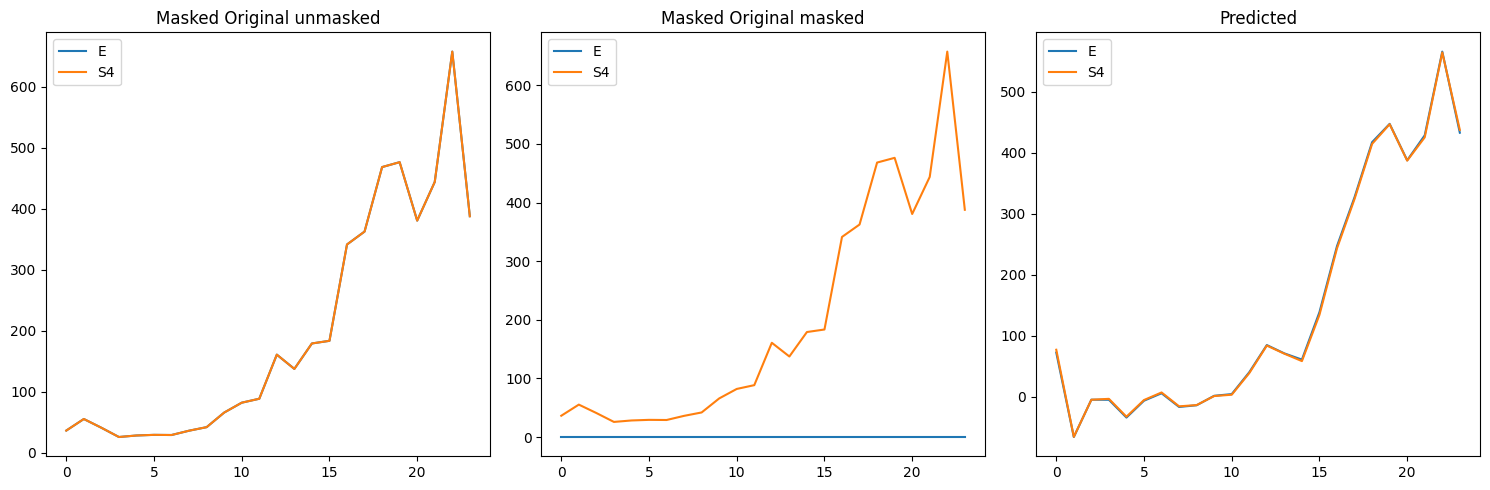

In [209]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS:,:]
DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values)

SIM_DS = SlidingWindowSensorDataset(DATA_RAW_SIMULATION_T, LEAF_INDICES, HIST_STEPS)  
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)


X_masked, X_unmasked,_ = next(iter((SIM_DL)))
print(f"X_masked: {X_masked.shape}")

MODEL.eval()
with torch.no_grad():
    Y_pred = MODEL(x=X_masked, adj_mask=ATT_MASK_T)

print(f"Y_pred: {Y_pred_scaled.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Masked Original unmasked')
pd.DataFrame(X_masked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original masked')
pd.DataFrame(Y_pred[0].detach().T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()


### SCENARIO: DROP 50%

In [ ]:
def reconstruct_physical_flow_mask(model, dataloader, scaler_means, scaler_stds, inner_mask, device='cpu'):
    """
    Reconstructs the timeline by merging ground truth leaf nodes with predicted inner nodes.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        inner_mask (list or np.ndarray): 1 (or True) for inner nodes, 0 for leaf nodes.
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: The merged physical flows. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: The original true flows (for reference). Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    # Ensure the mask is a boolean numpy array for easy indexing later
    mask_np = np.array(inner_mask, dtype=bool)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x_scaled_maked, y_true_scaled in dataloader:
            x_scaled_maked = x_scaled_maked.to(device)
            y_true_scaled = y_true_scaled.to(device)
            
            # 1. Forward pass
            y_pred_scaled = model(x_scaled_maked)
            
            # 2. Unscale back to physical flow units
            y_pred_unscaled = (y_pred_scaled * stds) + means
            y_true_unscaled = (y_true_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = y_pred_unscaled.cpu().numpy()
            trues_np = y_true_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)  [1,16]
            step_preds = preds_np[:, -1, :] 
            step_trues = trues_np[:, -1, :]

            #mantener los valores de las hojas
            #step_preds[:, ~mask_np] = step_trues[:, ~mask_np]

           
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # Concatenate all batches vertically
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    # ---------------------------------------------------------
    # 4. MERGE TRUES AND PREDICTIONS
    # ---------------------------------------------------------
    # Start with a copy of the perfect ground truth data
    merged_flows = final_trues.copy()
    
    # Overwrite ONLY the inner nodes with the model's predictions
    # mask_np is True for inner nodes, False for leaf nodes
    merged_flows[:, mask_np] = final_preds[:, mask_np]
    
    return merged_flows, final_trues

X_masked: torch.Size([1, 16, 24])
Y_pred: torch.Size([1, 16, 24])


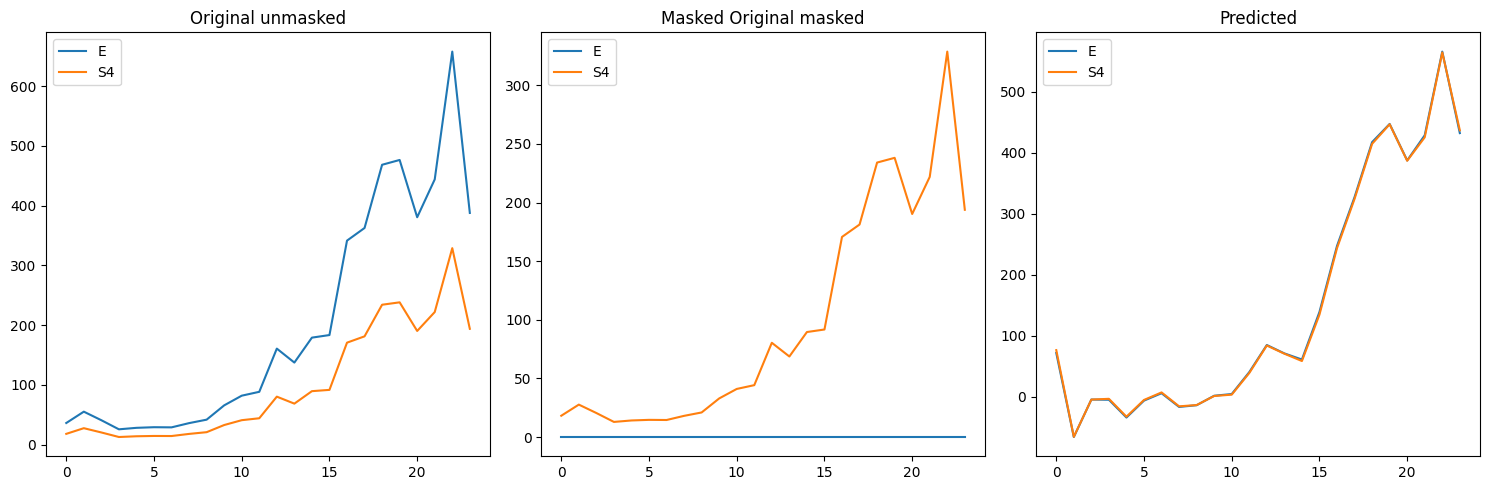

In [208]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS:,:]
DATA_RAW_SIMULATION['S4'] *= .5

DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values)

SIM_DS = SlidingWindowSensorDataset(DATA_RAW_SIMULATION_T, LEAF_INDICES, HIST_STEPS)  
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)


X_masked, X_unmasked,_ = next(iter((SIM_DL)))
print(f"X_masked: {X_masked.shape}")

MODEL.eval()
with torch.no_grad():
    Y_pred = MODEL(x=X_masked, adj_mask=ATT_MASK_T)

print(f"Y_pred: {Y_pred_scaled.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Original unmasked')
pd.DataFrame(X_masked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original masked')
pd.DataFrame(Y_pred[0].detach().T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()






In [265]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS:,:]
DATA_RAW_SIMULATION['S4'] *= .5

DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values)

SIM_DS = SlidingWindowSensorDataset(DATA_RAW_SIMULATION_T, LEAF_INDICES, HIST_STEPS) 
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)


data_simulation = DATA_RAW_SIMULATION_T

#LEAF_MASK = (1-INNER_MASK).astype(bool)

for i in range((HIST_STEPS*10)):
    print(f"HIST {i}")

    _sim_ds = SlidingWindowSensorDataset(data_simulation, LEAF_INDICES, HIST_STEPS) 
    _X_masked, _Y_true,_ = _sim_ds[0]

    #display(f"_X_masked_scaled.shape: {_X_masked_scaled.shape}")
    #display(f"_X_true_scaled.shape: {_X_true_scaled.shape}")

    with torch.no_grad():
        _pred = MODEL(x=_X_masked, adj_mask=ATT_MASK_T)

    _pred_scaled_last = _pred[0].T[-1].unsqueeze(0).numpy()

    #_pred_unscaled = (_pred_scaled*SCALER_STD_T) + SCALER_MEAN_T


    #display(f"_pred_scaled_last.shape: {_pred_scaled_last.shape}")
    #display(f"data_simulation_scaled.shape: {data_simulation_scaled.shape}")

    #_pred_df = pd.DataFrame([_pred_scaled_last], columns=NODE_LIST, index=[DATA_RAW_SIMULATION.index[i]])
    #display(_pred_df)

    #display(data_simulation.numpy().shape)
    #display(_pred_scaled_last.shape)

    data_simulation = np.concatenate([data_simulation.numpy(), _pred_scaled_last], axis=0)
    #display(data_simulation.shape)
    data_simulation = data_simulation[-HIST_STEPS:,:]
    #display(data_simulation.shape)

    data_simulation = torch.tensor(data_simulation).float()
    
    
    #data_simulation_scaled[:,LEAF_MASK] = _X_true_scaled[:,LEAF_MASK]
    

    #display(data_simulation_scaled.shape)
    

HIST 0
HIST 1
HIST 2
HIST 3
HIST 4
HIST 5
HIST 6
HIST 7
HIST 8
HIST 9
HIST 10
HIST 11
HIST 12
HIST 13
HIST 14
HIST 15
HIST 16
HIST 17
HIST 18
HIST 19
HIST 20
HIST 21
HIST 22
HIST 23
HIST 24
HIST 25
HIST 26
HIST 27
HIST 28
HIST 29
HIST 30
HIST 31
HIST 32
HIST 33
HIST 34
HIST 35
HIST 36
HIST 37
HIST 38
HIST 39
HIST 40
HIST 41
HIST 42
HIST 43
HIST 44
HIST 45
HIST 46
HIST 47
HIST 48
HIST 49
HIST 50
HIST 51
HIST 52
HIST 53
HIST 54
HIST 55
HIST 56
HIST 57
HIST 58
HIST 59
HIST 60
HIST 61
HIST 62
HIST 63
HIST 64
HIST 65
HIST 66
HIST 67
HIST 68
HIST 69
HIST 70
HIST 71
HIST 72
HIST 73
HIST 74
HIST 75
HIST 76
HIST 77
HIST 78
HIST 79
HIST 80
HIST 81
HIST 82
HIST 83
HIST 84
HIST 85
HIST 86
HIST 87
HIST 88
HIST 89
HIST 90
HIST 91
HIST 92
HIST 93
HIST 94
HIST 95
HIST 96
HIST 97
HIST 98
HIST 99
HIST 100
HIST 101
HIST 102
HIST 103
HIST 104
HIST 105
HIST 106
HIST 107
HIST 108
HIST 109
HIST 110
HIST 111
HIST 112
HIST 113
HIST 114
HIST 115
HIST 116
HIST 117
HIST 118
HIST 119
HIST 120
HIST 121
HIST 122
HIS

In [266]:
HIST_STEPS

24

<Axes: >

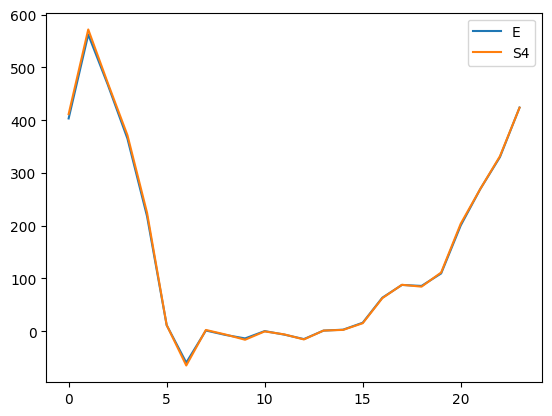

In [267]:
pd.DataFrame(data_simulation.numpy(), columns=NODE_LIST)[['E','S4']].plot()